# 25 · Position Sizing: The Kelly Criterion and Volatility Targeting

*Module 6 — Risk Management*

Knowing which trade to make is only half the problem. This notebook shows, with real derivations and a controlled simulation, why *how much* to bet is just as consequential — and why betting the mathematically "optimal" amount is, in practice, usually a mistake.

## 1. Motivation

Two traders share the exact same genuine edge — the same expected return, the same volatility, the same win rate. One sizes positions carefully; the other bets far too aggressively on the same signal. Over a long enough horizon, the second trader is not just a little worse off — they can plausibly end up *poorer than when they started*, despite trading with a real, positive edge the entire time. Position sizing is not a footnote to a trading strategy; it is frequently the difference between the same underlying edge compounding into real wealth or evaporating into a sequence of unlucky, oversized bets.

## 2. Intuition

The **Kelly criterion** answers a precise question: given a repeated bet with a known edge, what fraction of your current capital should you wager each time to maximize the long-run *growth rate* of your wealth? The answer is not "as much as possible" — betting too aggressively means occasional large losses shrink your capital so much that even a positive average edge cannot compound its way back at the same pace. The Kelly fraction is the single sizing choice that walks the precise line between "growing too slowly by underbetting" and "destroying compounding by overbetting."

In practice, almost nobody bets *full* Kelly, for a reason this notebook demonstrates rather than just asserts: Kelly's formula assumes you *know* your true edge exactly. In reality you only ever have a noisy *estimate* of it (exactly the estimation-error theme from Notebook 5), and betting full-Kelly-sized positions on an estimate that might be wrong is far riskier than the textbook formula, which assumes certainty, would suggest.

**Volatility targeting** takes a completely different, complementary approach: instead of using a return forecast at all, size positions purely to keep the portfolio's *risk* — its volatility — roughly constant over time, scaling exposure down when markets get turbulent and up when they calm down. It says nothing about which trades are good; it only tries to make sure no single period's risk is wildly out of line with any other's.

## 3. Theory

### 3.1 The Kelly criterion, derived

Consider betting a fraction $f$ of current wealth each period, on a bet with per-period return $R$ (mean $\mu$, variance $\sigma^2$). Wealth evolves multiplicatively: $W_t = W_0\prod_t(1+fR_t)$. The long-run growth rate is governed by the *expected log return*, since $\log W_T = \log W_0 + \sum_t \log(1+fR_t)$, and by the law of large numbers this sum grows at rate $\mathbb E[\log(1+fR)]$ per period. Maximizing long-run growth means maximizing $\mathbb E[\log(1+fR)]$ over $f$.

For returns small relative to 1 (a reasonable approximation for typical trading returns), Taylor-expand: $\log(1+fR) \approx fR - \tfrac12(fR)^2$, so

$$
\mathbb E[\log(1+fR)] \approx f\mu - \tfrac12 f^2(\sigma^2+\mu^2) \approx f\mu - \tfrac12 f^2\sigma^2
$$

(dropping $\mu^2$ as negligible next to $\sigma^2$ for typical parameters). This is a downward parabola in $f$; setting its derivative to zero, $\mu - f\sigma^2=0$, gives the celebrated result:

$$
\boxed{\; f^\ast = \frac{\mu}{\sigma^2} \;}
$$

— the Kelly-optimal fraction is the edge, scaled by inverse variance. Notice this is exactly the Sharpe ratio divided by volatility, $f^\ast = (\mu/\sigma)/\sigma$: a cleaner edge, or a calmer asset, both call for a larger optimal bet size.

**A clean, important side-result**: because the growth-rate function $g(f)=f\mu-\tfrac12f^2\sigma^2$ is an exact parabola, $g(f^\ast)=\mu^2/(2\sigma^2)$ is the maximum, and — substitute directly — $g(2f^\ast) = 2f^\ast\mu - \tfrac12(2f^\ast)^2\sigma^2 = 2\frac{\mu^2}{\sigma^2} - 2\frac{\mu^2}{\sigma^2} = 0$. **Betting exactly twice the Kelly fraction gives a long-run growth rate of exactly zero** — all of the edge is destroyed by the extra variance, even though the bet still has a positive expected *simple* return every single period. We verify this striking fact directly in Section 4.

### 3.2 Why fractional Kelly is the practical standard

Full Kelly assumes $\mu$ is known exactly. In reality, $\mu$ is estimated from finite, noisy data — and the growth-rate parabola from Section 3.1 is not symmetric in its consequences: betting on an *overestimated* $\hat\mu$ pushes $f$ toward or past $2f^\ast_{\text{true}}$, where growth collapses toward zero or negative, while underbetting from an *underestimated* $\hat\mu$ only costs some growth, never catastrophically. Betting a fraction (commonly $\tfrac12$ or $\tfrac14$) of the *estimated* Kelly size is a direct, practical hedge against exactly this asymmetry — we demonstrate its effect on realistic, noisy edge estimates in Section 5.

### 3.3 Volatility targeting

Rather than using any return forecast, scale exposure inversely to recently realized volatility:

$$
w_t = \frac{\sigma_{\text{target}}}{\hat\sigma_{t-1}} ,
$$

where $\hat\sigma_{t-1}$ is a trailing realized-volatility estimate (using only information available *before* period $t$, to avoid look-ahead) and $\sigma_{\text{target}}$ is the desired constant portfolio volatility. This is a purely risk-based rule — it makes no claim about expected returns at all, much like Notebook 7's risk parity and Notebook 8's HRP.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(151)

## 4. Implementation

### 4.1 Full Kelly, fractional Kelly, and the "2x Kelly gives zero growth" result

We simulate many independent wealth paths under a **known, fixed** true edge, so any difference between strategies is purely about sizing, not estimation.

In [2]:
mu_true, sigma_true = 0.0006, 0.011      # a modest, realistic daily edge and volatility
kelly_f = mu_true / sigma_true**2
print(f"True Kelly fraction f* = mu/sigma^2 = {kelly_f:.2f}")

def simulate_wealth(f, mu, sigma, n_days, n_paths, seed):
    local_rng = np.random.default_rng(seed)
    rets = local_rng.normal(mu, sigma, size=(n_paths, n_days))
    return np.cumprod(1 + f * rets, axis=1)

n_days, n_paths = 2000, 3000
rows = []
for label, frac in [('Full Kelly', 1.0), ('Half Kelly', 0.5), ('Quarter Kelly', 0.25), ('2x Kelly (overbet)', 2.0)]:
    W = simulate_wealth(kelly_f * frac, mu_true, sigma_true, n_days, n_paths, seed=1)
    rows.append({'strategy': label, 'median_final_wealth': np.median(W[:, -1]),
                 'mean_log_growth': np.log(W[:, -1]).mean(),
                 'P(wealth ever < 10% of start)': (W.min(axis=1) < 0.1).mean()})
pd.DataFrame(rows).round(3)

True Kelly fraction f* = mu/sigma^2 = 4.96


,strategy,median_final_wealth,mean_log_growth,P(wealth ever < 10% of start)
0,Full Kelly,20.835,3.043,0.070
1,Half Kelly,9.612,2.266,0.001
2,Quarter Kelly,3.725,1.319,0.000
3,2x Kelly (overbet),0.998,0.036,0.617


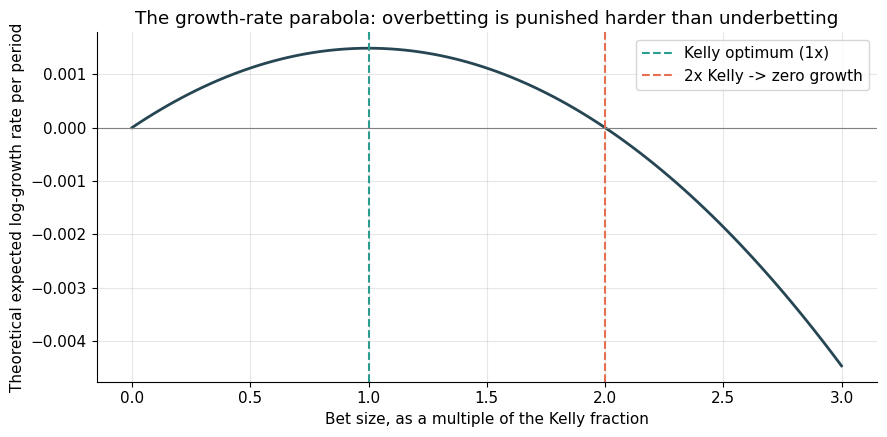

In [3]:
f_grid = np.linspace(0, 3*kelly_f, 100)
theoretical_growth = f_grid*mu_true - 0.5*f_grid**2*sigma_true**2

fig, ax = plt.subplots()
ax.plot(f_grid/kelly_f, theoretical_growth, color='#264653', linewidth=2)
ax.axvline(1.0, color='#2a9d8f', linestyle='--', label='Kelly optimum (1x)')
ax.axvline(2.0, color='#e76f51', linestyle='--', label='2x Kelly -> zero growth')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Bet size, as a multiple of the Kelly fraction')
ax.set_ylabel('Theoretical expected log-growth rate per period')
ax.set_title('The growth-rate parabola: overbetting is punished harder than underbetting')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Does fractional Kelly actually help when the edge is only ESTIMATED?

Now the more realistic, and more important, test: the trader does not know $\mu_{true}$. Each simulated "world" gives them one year of data to estimate it, and they size positions based on that noisy estimate — with performance then evaluated going forward using the (still unknown to them) true edge.

In [4]:
n_estimation_days, n_forward_days, n_worlds = 250, 1000, 3000
true_mu = 0.0005

outcomes = {'Full Kelly (on estimate)': [], 'Half Kelly (on estimate)': [], 'Quarter Kelly (on estimate)': []}
for w in range(n_worlds):
    est_sample = rng.normal(true_mu, sigma_true, n_estimation_days)
    mu_hat = est_sample.mean()                     # the trader's only knowledge of the edge: a noisy estimate
    kelly_hat = mu_hat / sigma_true**2

    forward_rets = rng.normal(true_mu, sigma_true, n_forward_days)   # actual future returns use the TRUE mu
    for label, frac in [('Full Kelly (on estimate)', 1.0), ('Half Kelly (on estimate)', 0.5),
                         ('Quarter Kelly (on estimate)', 0.25)]:
        wealth_path = np.cumprod(1 + kelly_hat*frac * forward_rets)
        outcomes[label].append(wealth_path[-1])

rows = []
for label, vals in outcomes.items():
    vals = np.array(vals)
    rows.append({'strategy': label, 'median_final_wealth': np.median(vals),
                 'mean_log_growth': np.log(np.clip(vals, 1e-9, None)).mean(),
                 'P(final wealth < 0.5x starting)': (vals < 0.5).mean()})
pd.DataFrame(rows).round(3)

,strategy,median_final_wealth,mean_log_growth,P(final wealth < 0.5x starting)
0,Full Kelly (on estimate),0.958,-0.926,0.389
1,Half Kelly (on estimate),1.327,0.328,0.184
2,Quarter Kelly (on estimate),1.290,0.358,0.076


### Interpreting the result

This is the practical case for fractional Kelly, made concrete rather than asserted. Betting full Kelly *on a noisy estimate* of the edge can produce a **negative** average log-growth rate — a trader following the textbook-optimal formula to the letter, using perfectly reasonable statistical estimation, ends up losing money on average, purely because estimation noise occasionally pushes their bet size well past the true optimum, into the steeply-punished region of the parabola from Section 4.1. Betting only a half or a quarter of the estimated Kelly fraction gives up some average growth in exchange for dramatically less exposure to exactly this danger — a direct, quantified version of the standard practitioner wisdom "never bet full Kelly," grounded in the same estimation-uncertainty theme that has run through this entire course since Notebook 5.

## 5. Worked example: volatility targeting

In [5]:
n = 2500
kappa_sig, theta_logsig, eta = 0.02, np.log(0.16), 0.08     # reuse the stochastic-vol process from Notebook 13
log_sigma = np.zeros(n)
log_sigma[0] = theta_logsig
for t in range(1, n):
    log_sigma[t] = log_sigma[t-1] + kappa_sig*(theta_logsig - log_sigma[t-1]) + eta*rng.normal()
sigma_ann = np.exp(log_sigma)
sigma_daily = sigma_ann / np.sqrt(252)
returns = pd.Series(rng.normal(0.0003, sigma_daily))

TARGET_VOL_ANN = 0.12
realized_vol = returns.rolling(20).std() * np.sqrt(252)
exposure = (TARGET_VOL_ANN / realized_vol).clip(upper=3).shift(1)     # yesterday's info only -- no look-ahead

vol_targeted_returns = (exposure * returns).dropna()
constant_returns = returns.reindex(vol_targeted_returns.index)

def perf_stats(r):
    ann_ret, ann_vol = r.mean()*252, r.std()*np.sqrt(252)
    cum = (1+r).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    return ann_ret, ann_vol, ann_ret/ann_vol, max_dd

for name, r in [('Constant exposure', constant_returns), ('Volatility-targeted', vol_targeted_returns)]:
    ar, av, sh, dd = perf_stats(r)
    print(f"{name:20s} ann.ret {ar:6.2%}  ann.vol {av:6.2%}  Sharpe {sh:5.2f}  max DD {dd:7.2%}")

roll_vol_const = constant_returns.rolling(60).std() * np.sqrt(252)
roll_vol_vt = vol_targeted_returns.rolling(60).std() * np.sqrt(252)
print(f"\nStability of realized volatility itself (std of the 60-day rolling vol estimate):")
print(f"  Constant exposure:    {roll_vol_const.std():.4f}")
print(f"  Volatility-targeted:  {roll_vol_vt.std():.4f}")

Constant exposure    ann.ret  2.10%  ann.vol 17.63%  Sharpe  0.12  max DD -42.18%
Volatility-targeted  ann.ret  1.29%  ann.vol 13.02%  Sharpe  0.10  max DD -34.69%

Stability of realized volatility itself (std of the 60-day rolling vol estimate):
  Constant exposure:    0.0516
  Volatility-targeted:  0.0136


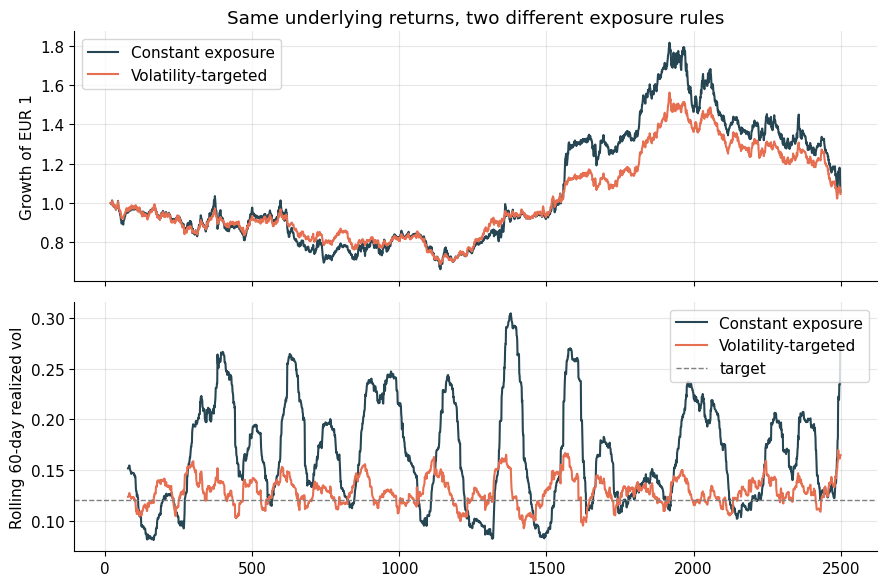

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot((1+constant_returns).cumprod(), label='Constant exposure', color='#264653')
axes[0].plot((1+vol_targeted_returns).cumprod(), label='Volatility-targeted', color='#e76f51')
axes[0].set_ylabel('Growth of EUR 1')
axes[0].legend()
axes[0].set_title('Same underlying returns, two different exposure rules')

axes[1].plot(roll_vol_const, label='Constant exposure', color='#264653')
axes[1].plot(roll_vol_vt, label='Volatility-targeted', color='#e76f51')
axes[1].axhline(TARGET_VOL_ANN, color='gray', linestyle='--', linewidth=1, label='target')
axes[1].set_ylabel('Rolling 60-day realized vol')
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpreting the result

Report your own run's exact numbers, but the *mechanical* effect should be unambiguous every time: the rolling realized-volatility chart for the volatility-targeted series hugs the target line far more tightly than the wildly swinging constant-exposure line does — this is the one thing volatility targeting is directly designed to do, and it does it reliably. Its effect on Sharpe ratio and maximum drawdown is genuinely more mixed and sample-dependent (it says nothing about expected returns at all, and de-risking during a period that turns out to recover quickly can cost as much as it saves during a period that turns out to keep falling) — a more honest characterization than a blanket "vol targeting improves performance" claim would be.

## 6. Limitations and pitfalls

- **The Gaussian, small-return Kelly approximation breaks down for fat-tailed or highly skewed return distributions** — exactly the kind of return profile Notebook 12's carry trades and Notebook 13's short-volatility strategies produce. A more careful Kelly analysis for such strategies needs the full (non-Taylor-approximated) expected-log-return optimization, not the clean closed form derived here.
- **Kelly assumes bets are i.i.d. and repeated indefinitely.** Real trading opportunities are correlated across time and across positions (the same underlying market risk shows up in many "independent-looking" bets at once) — applying single-bet Kelly sizing naively to a portfolio of correlated positions overstates how much genuine diversification of risk is actually happening.
- **Volatility targeting can itself amplify trend-following-like behavior in a destabilizing way at the market level.** If many participants simultaneously de-risk when volatility rises, that collective selling can itself contribute to further volatility and price declines — a systemic effect no individual volatility-targeting rule accounts for on its own.
- **Both approaches need a volatility estimate, and estimating volatility is itself imperfect** (Notebook 13's stochastic-volatility discussion applies directly) — a badly lagging or badly mis-specified volatility estimate undermines either method regardless of how correct the underlying sizing logic is.
- **Neither Kelly nor volatility targeting accounts for transaction costs of the resulting position changes** — a very actively rebalanced sizing rule can generate meaningful turnover, a cost this notebook did not model (Notebook 28 addresses this directly).

## 7. Exercises

**1. Verify the zero-growth point yourself (warm-up).**
Using the `theoretical_growth` formula from Section 4.1, confirm algebraically (not just from the chart) that $g(2f^\ast)=0$ for *any* choice of $\mu>0,\sigma>0$, not just the specific values used in this notebook. Then find the bet-size multiple (as a fraction of $f^\ast$) at which growth rate is exactly *half* of its maximum value, and verify it numerically.

**2. How much data do you need before full Kelly is reasonably safe?**
Repeat Section 4.2's estimation-uncertainty experiment, varying `n_estimation_days` from 60 to 2000. Plot Full Kelly's mean log-growth rate (evaluated using the true $\mu$) against the amount of estimation data used. Roughly how much historical data would you want before full Kelly's estimation risk becomes small enough that it starts to look competitive with Half Kelly?

**3. Combine Kelly sizing with volatility targeting.**
Design a combined sizing rule: use a rolling estimate of both $\hat\mu_t$ and $\hat\sigma_t$ (e.g., trailing 60-day mean and volatility) to compute a *time-varying* fractional-Kelly position size $w_t = \text{frac} \times \hat\mu_t/\hat\sigma_t^2$, using only information available before $t$. Backtest this on the Section 5 stochastic-volatility return series, and compare its realized Sharpe ratio, volatility stability, and maximum drawdown to both the pure volatility-targeting rule and a naive constant-fraction Kelly rule that ignores the time-varying mean entirely. Does combining a (noisy) return forecast with volatility scaling help, hurt, or make little difference here?